# Libraries

In [1]:
# Data Preparation
import numpy as np
import pandas as pd
# Data Vizulaization
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Data Preparation

# 1.1.Data Understanding

In [2]:
# Read the Data 
data = pd.read_csv('dataset\mental_health_dataset.csv')
df = data.copy()
df.head()

<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9028\632273665.py:2: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  data = pd.read_csv('dataset\mental_health_dataset.csv')


,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,Male,Employed,On-site,Yes,Yes,6,6.2,3,28,17,54,59.7,High
1,46,Female,Student,On-site,No,Yes,10,9.0,4,30,11,85,54.9,High
2,32,Female,Employed,On-site,Yes,No,7,7.7,2,24,7,62,61.3,Medium
3,60,Non-binary,Self-employed,On-site,No,No,4,4.5,4,6,0,95,97.0,Low
4,25,Female,Self-employed,On-site,Yes,Yes,3,5.4,0,24,12,70,69.0,High


In [3]:
# Size of Data
df.shape

(10000, 14)

In [4]:
# Information of Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     10000 non-null  int64  
 1   gender                  10000 non-null  object 
 2   employment_status       10000 non-null  object 
 3   work_environment        10000 non-null  object 
 4   mental_health_history   10000 non-null  object 
 5   seeks_treatment         10000 non-null  object 
 6   stress_level            10000 non-null  int64  
 7   sleep_hours             10000 non-null  float64
 8   physical_activity_days  10000 non-null  int64  
 9   depression_score        10000 non-null  int64  
 10  anxiety_score           10000 non-null  int64  
 11  social_support_score    10000 non-null  int64  
 12  productivity_score      10000 non-null  float64
 13  mental_health_risk      10000 non-null  object 
dtypes: float64(2), int64(6), object(6)
memo

In [5]:
# Check Names Of columns
df.columns

Index(['age', 'gender', 'employment_status', 'work_environment',
       'mental_health_history', 'seeks_treatment', 'stress_level',
       'sleep_hours', 'physical_activity_days', 'depression_score',
       'anxiety_score', 'social_support_score', 'productivity_score',
       'mental_health_risk'],
      dtype='object')

In [6]:
# Check Description (Statistics)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10000.0,41.55760,13.749581,18.0,30.0,41.5,53.0,65.0
stress_level,10000.0,5.57200,2.887741,1.0,3.0,6.0,8.0,10.0
sleep_hours,10000.0,6.47300,1.473944,3.0,5.5,6.5,7.5,10.0
physical_activity_days,10000.0,3.50570,2.282737,0.0,2.0,4.0,5.0,7.0
depression_score,10000.0,15.03990,8.990839,0.0,7.0,15.0,23.0,30.0
anxiety_score,10000.0,10.56180,6.322640,0.0,5.0,11.0,16.0,21.0
social_support_score,10000.0,50.11770,29.229278,0.0,25.0,50.0,76.0,100.0
productivity_score,10000.0,77.31221,14.061202,42.8,65.8,77.6,89.2,100.0


In [7]:
# Number of Unique Columns
df.nunique()

age                        48
gender                      4
employment_status           4
work_environment            3
mental_health_history       2
seeks_treatment             2
stress_level               10
sleep_hours                71
physical_activity_days      8
depression_score           31
anxiety_score              22
social_support_score      101
productivity_score        546
mental_health_risk          3
dtype: int64

In [8]:
# Sample of Data
df.sample(5)

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
4050,26,Female,Student,Remote,No,No,6,5.2,4,17,15,52,76.5,Medium
6108,31,Female,Employed,Remote,No,No,4,8.4,2,26,10,12,62.9,High
5358,25,Female,Employed,On-site,No,No,1,8.7,7,10,1,14,85.9,Low
7742,29,Male,Student,Hybrid,No,No,1,5.1,3,11,20,63,99.2,Medium
9717,46,Female,Employed,Hybrid,Yes,Yes,7,8.9,1,1,13,38,100.0,Low


In [9]:
# Check Balance Of Data (Target Distribution)
df['mental_health_risk'].value_counts()

mental_health_risk
Medium    5892
High      2369
Low       1739
Name: count, dtype: int64

In [10]:
df['mental_health_risk'].value_counts(normalize=True) * 100

mental_health_risk
Medium    58.92
High      23.69
Low       17.39
Name: proportion, dtype: float64

# 2.Data Clean

In [11]:
# Count number of duplicate rows 
print('Number Of Duplicates = ',df.duplicated().sum())


Number Of Duplicates =  0


In [12]:
print(df.dtypes)

age                         int64
gender                     object
employment_status          object
work_environment           object
mental_health_history      object
seeks_treatment            object
stress_level                int64
sleep_hours               float64
physical_activity_days      int64
depression_score            int64
anxiety_score               int64
social_support_score        int64
productivity_score        float64
mental_health_risk         object
dtype: object


In [13]:
# Correct Data Types
cat_cols = ['gender','employment_status','work_environment','mental_health_history','seeks_treatment','mental_health_risk']

for col in cat_cols:
    df[col] = df[col].astype('category')
print(df.dtypes)

age                          int64
gender                    category
employment_status         category
work_environment          category
mental_health_history     category
seeks_treatment           category
stress_level                 int64
sleep_hours                float64
physical_activity_days       int64
depression_score             int64
anxiety_score                int64
social_support_score         int64
productivity_score         float64
mental_health_risk        category
dtype: object


In [14]:
# Handle Missing Values
df.isnull().sum()

age                       0
gender                    0
employment_status         0
work_environment          0
mental_health_history     0
seeks_treatment           0
stress_level              0
sleep_hours               0
physical_activity_days    0
depression_score          0
anxiety_score             0
social_support_score      0
productivity_score        0
mental_health_risk        0
dtype: int64

In [15]:
# 2) - Check Unique Value in categorical Data
cat_cols = ['gender','employment_status','work_environment','mental_health_history','seeks_treatment','mental_health_risk']


for col in cat_cols:
    print('=============== ',col,' ===============')
    print('Unique:', df[col].unique())
    print(50 * '=')

===============  gender  ===============
Unique: ['Male', 'Female', 'Non-binary', 'Prefer not to say']
Categories (4, object): ['Female', 'Male', 'Non-binary', 'Prefer not to say']
===============  employment_status  ===============
Unique: ['Employed', 'Student', 'Self-employed', 'Unemployed']
Categories (4, object): ['Employed', 'Self-employed', 'Student', 'Unemployed']
===============  work_environment  ===============
Unique: ['On-site', 'Remote', 'Hybrid']
Categories (3, object): ['Hybrid', 'On-site', 'Remote']
===============  mental_health_history  ===============
Unique: ['Yes', 'No']
Categories (2, object): ['No', 'Yes']
===============  seeks_treatment  ===============
Unique: ['Yes', 'No']
Categories (2, object): ['No', 'Yes']
===============  mental_health_risk  ===============
Unique: ['High', 'Medium', 'Low']
Categories (3, object): ['High', 'Low', 'Medium']



### **Outlier Flagging (IQR Method)**


In [16]:
numeric_cols = [
    'age',
    'stress_level',
    'sleep_hours',
    'physical_activity_days',
    'depression_score',
    'anxiety_score',
    'social_support_score',
    'productivity_score'
]

outlier_dict = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_dict[col] = outliers.shape[0]

outlier_dict

{'age': 0,
 'stress_level': 0,
 'sleep_hours': 0,
 'physical_activity_days': 0,
 'depression_score': 0,
 'anxiety_score': 0,
 'social_support_score': 0,
 'productivity_score': 0}

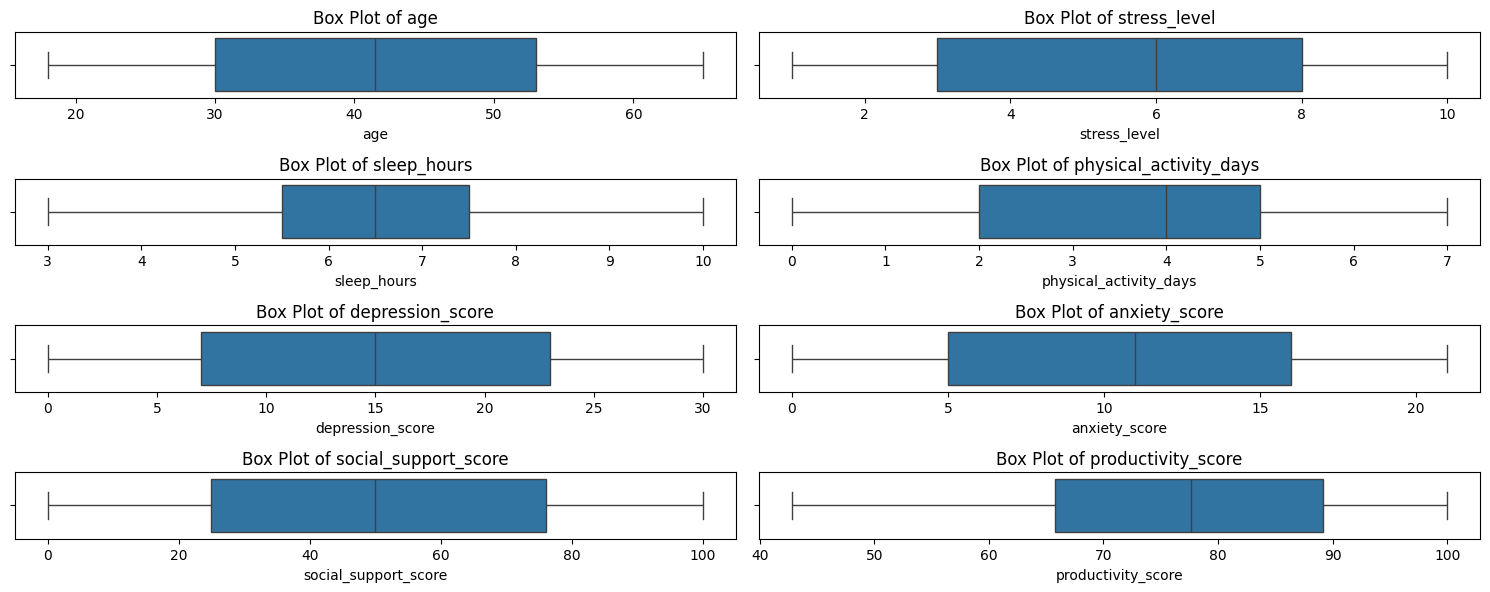

In [17]:
# Check Outlier
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numeric_cols):
    plt.subplot(7, 2, i + 1)
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns

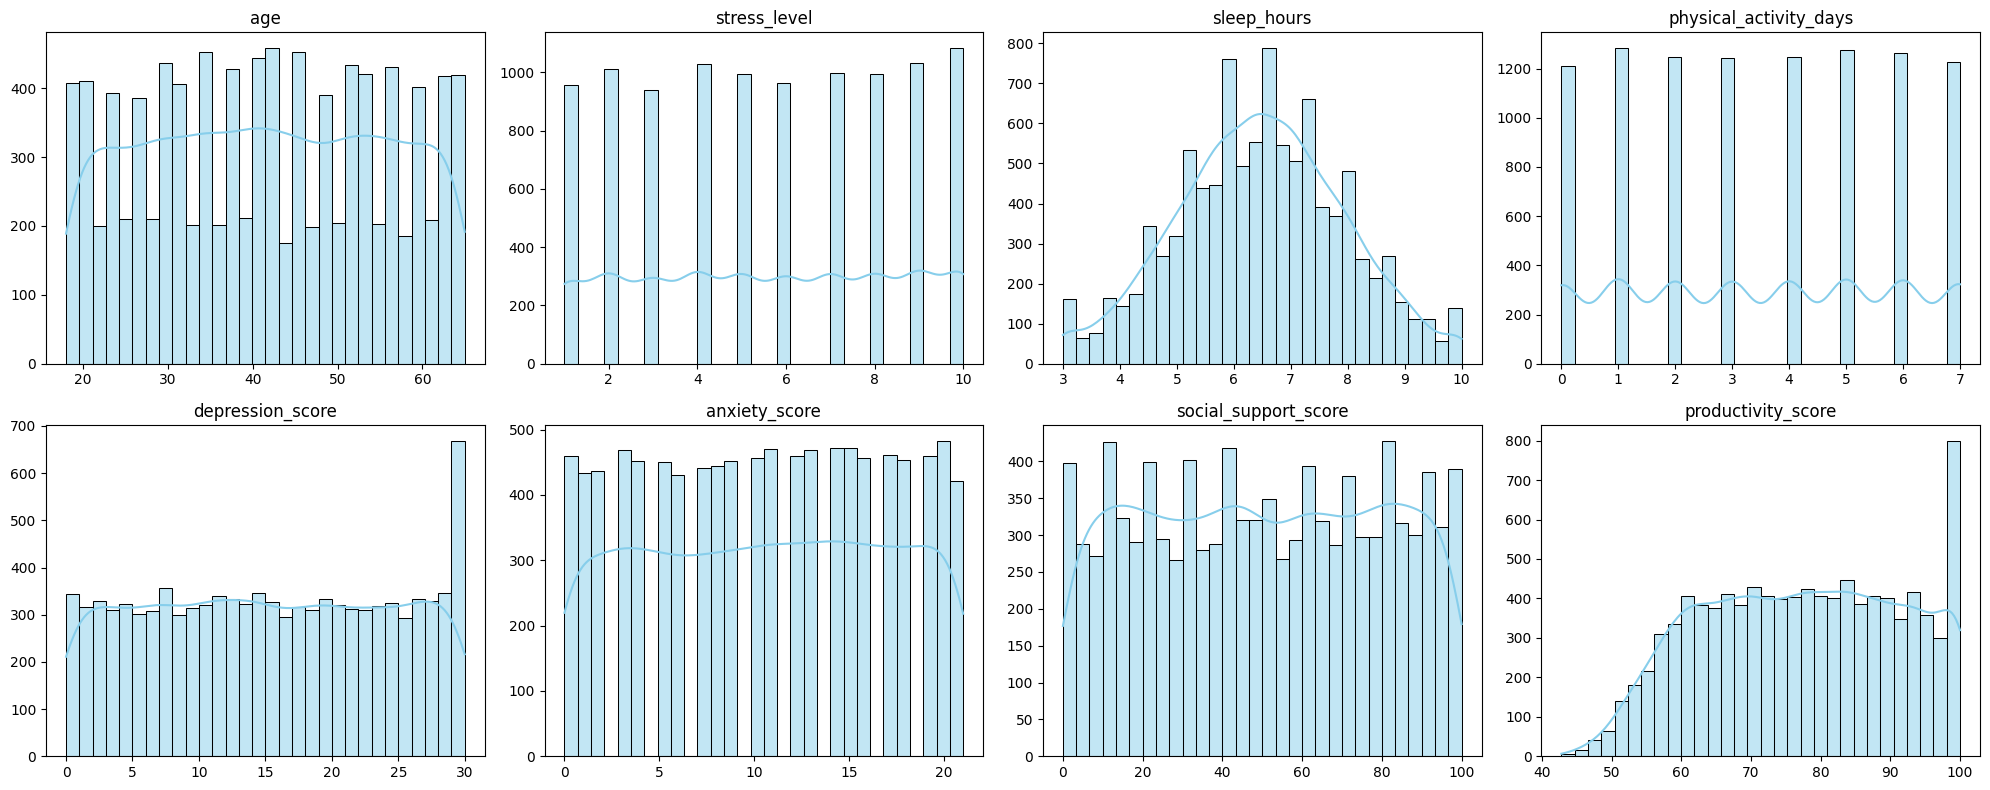

In [19]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Number of plots per row
plots_per_row = 4

# Calculate number of rows needed
n_cols = len(num_cols)
rows = math.ceil(n_cols / plots_per_row)

# Set overall figure size dynamically
plt.figure(figsize=(plots_per_row*5, rows*4))

# Loop through each numerical column
for i, col in enumerate(num_cols):
    plt.subplot(rows, plots_per_row, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(col, fontsize=12)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

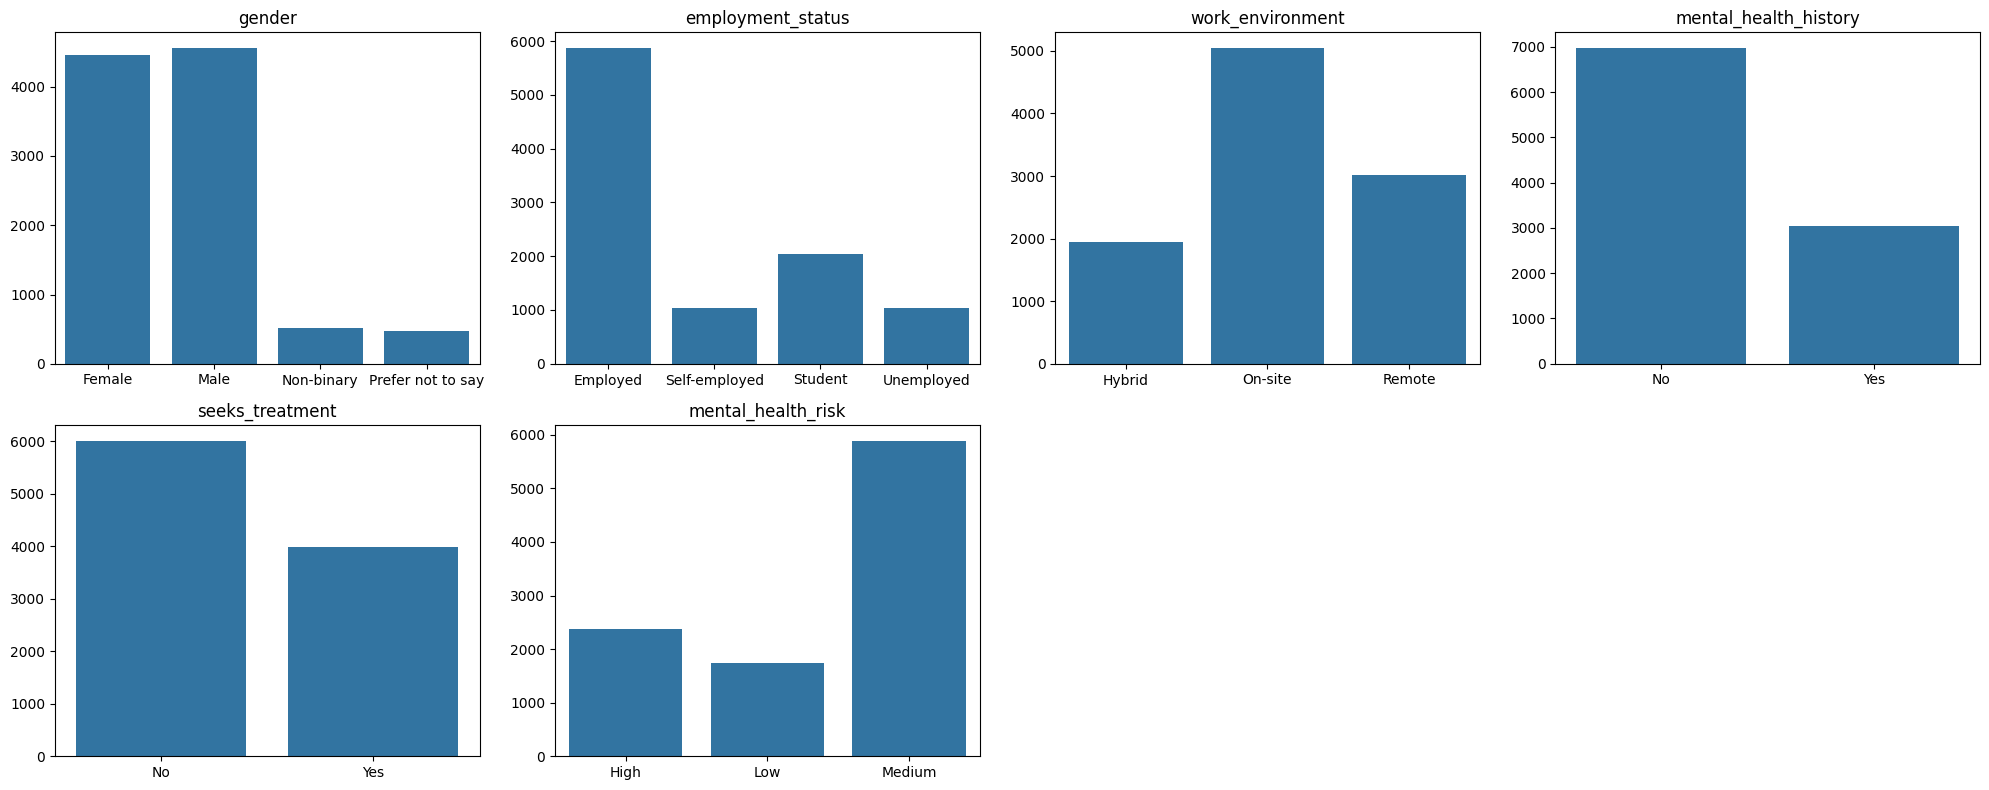

In [21]:
# Count plots for categorical features
n_cat = len(cat_cols)
plots_per_row = 4
rows_cat = math.ceil(n_cat / plots_per_row)

plt.figure(figsize=(plots_per_row*5, rows_cat*4))
for i, col in enumerate(cat_cols):
    plt.subplot(rows_cat, plots_per_row, i + 1)
    sns.countplot(x=df[col]) ## =====> Count Plot
    plt.title(f'{col}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()


In [22]:
skewness = df[num_cols].skew()

print("Skewness:")
print(skewness)

Skewness:
age                      -0.002027
stress_level             -0.019861
sleep_hours              -0.001903
physical_activity_days   -0.003336
depression_score          0.001152
anxiety_score            -0.023548
social_support_score     -0.004376
productivity_score       -0.079468
dtype: float64


In [23]:
kurtosis = df[num_cols].kurtosis()

print("Kurtosis:")
print(kurtosis)

Kurtosis:
age                      -1.179231
stress_level             -1.235173
sleep_hours              -0.318875
physical_activity_days   -1.237225
depression_score         -1.202421
anxiety_score            -1.199511
social_support_score     -1.213036
productivity_score       -1.053322
dtype: float64


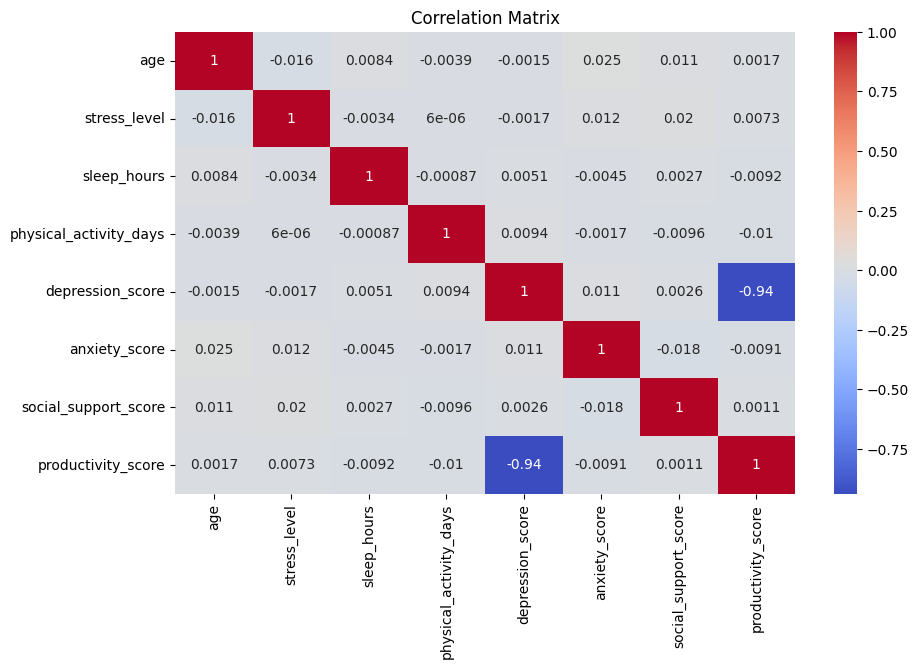

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

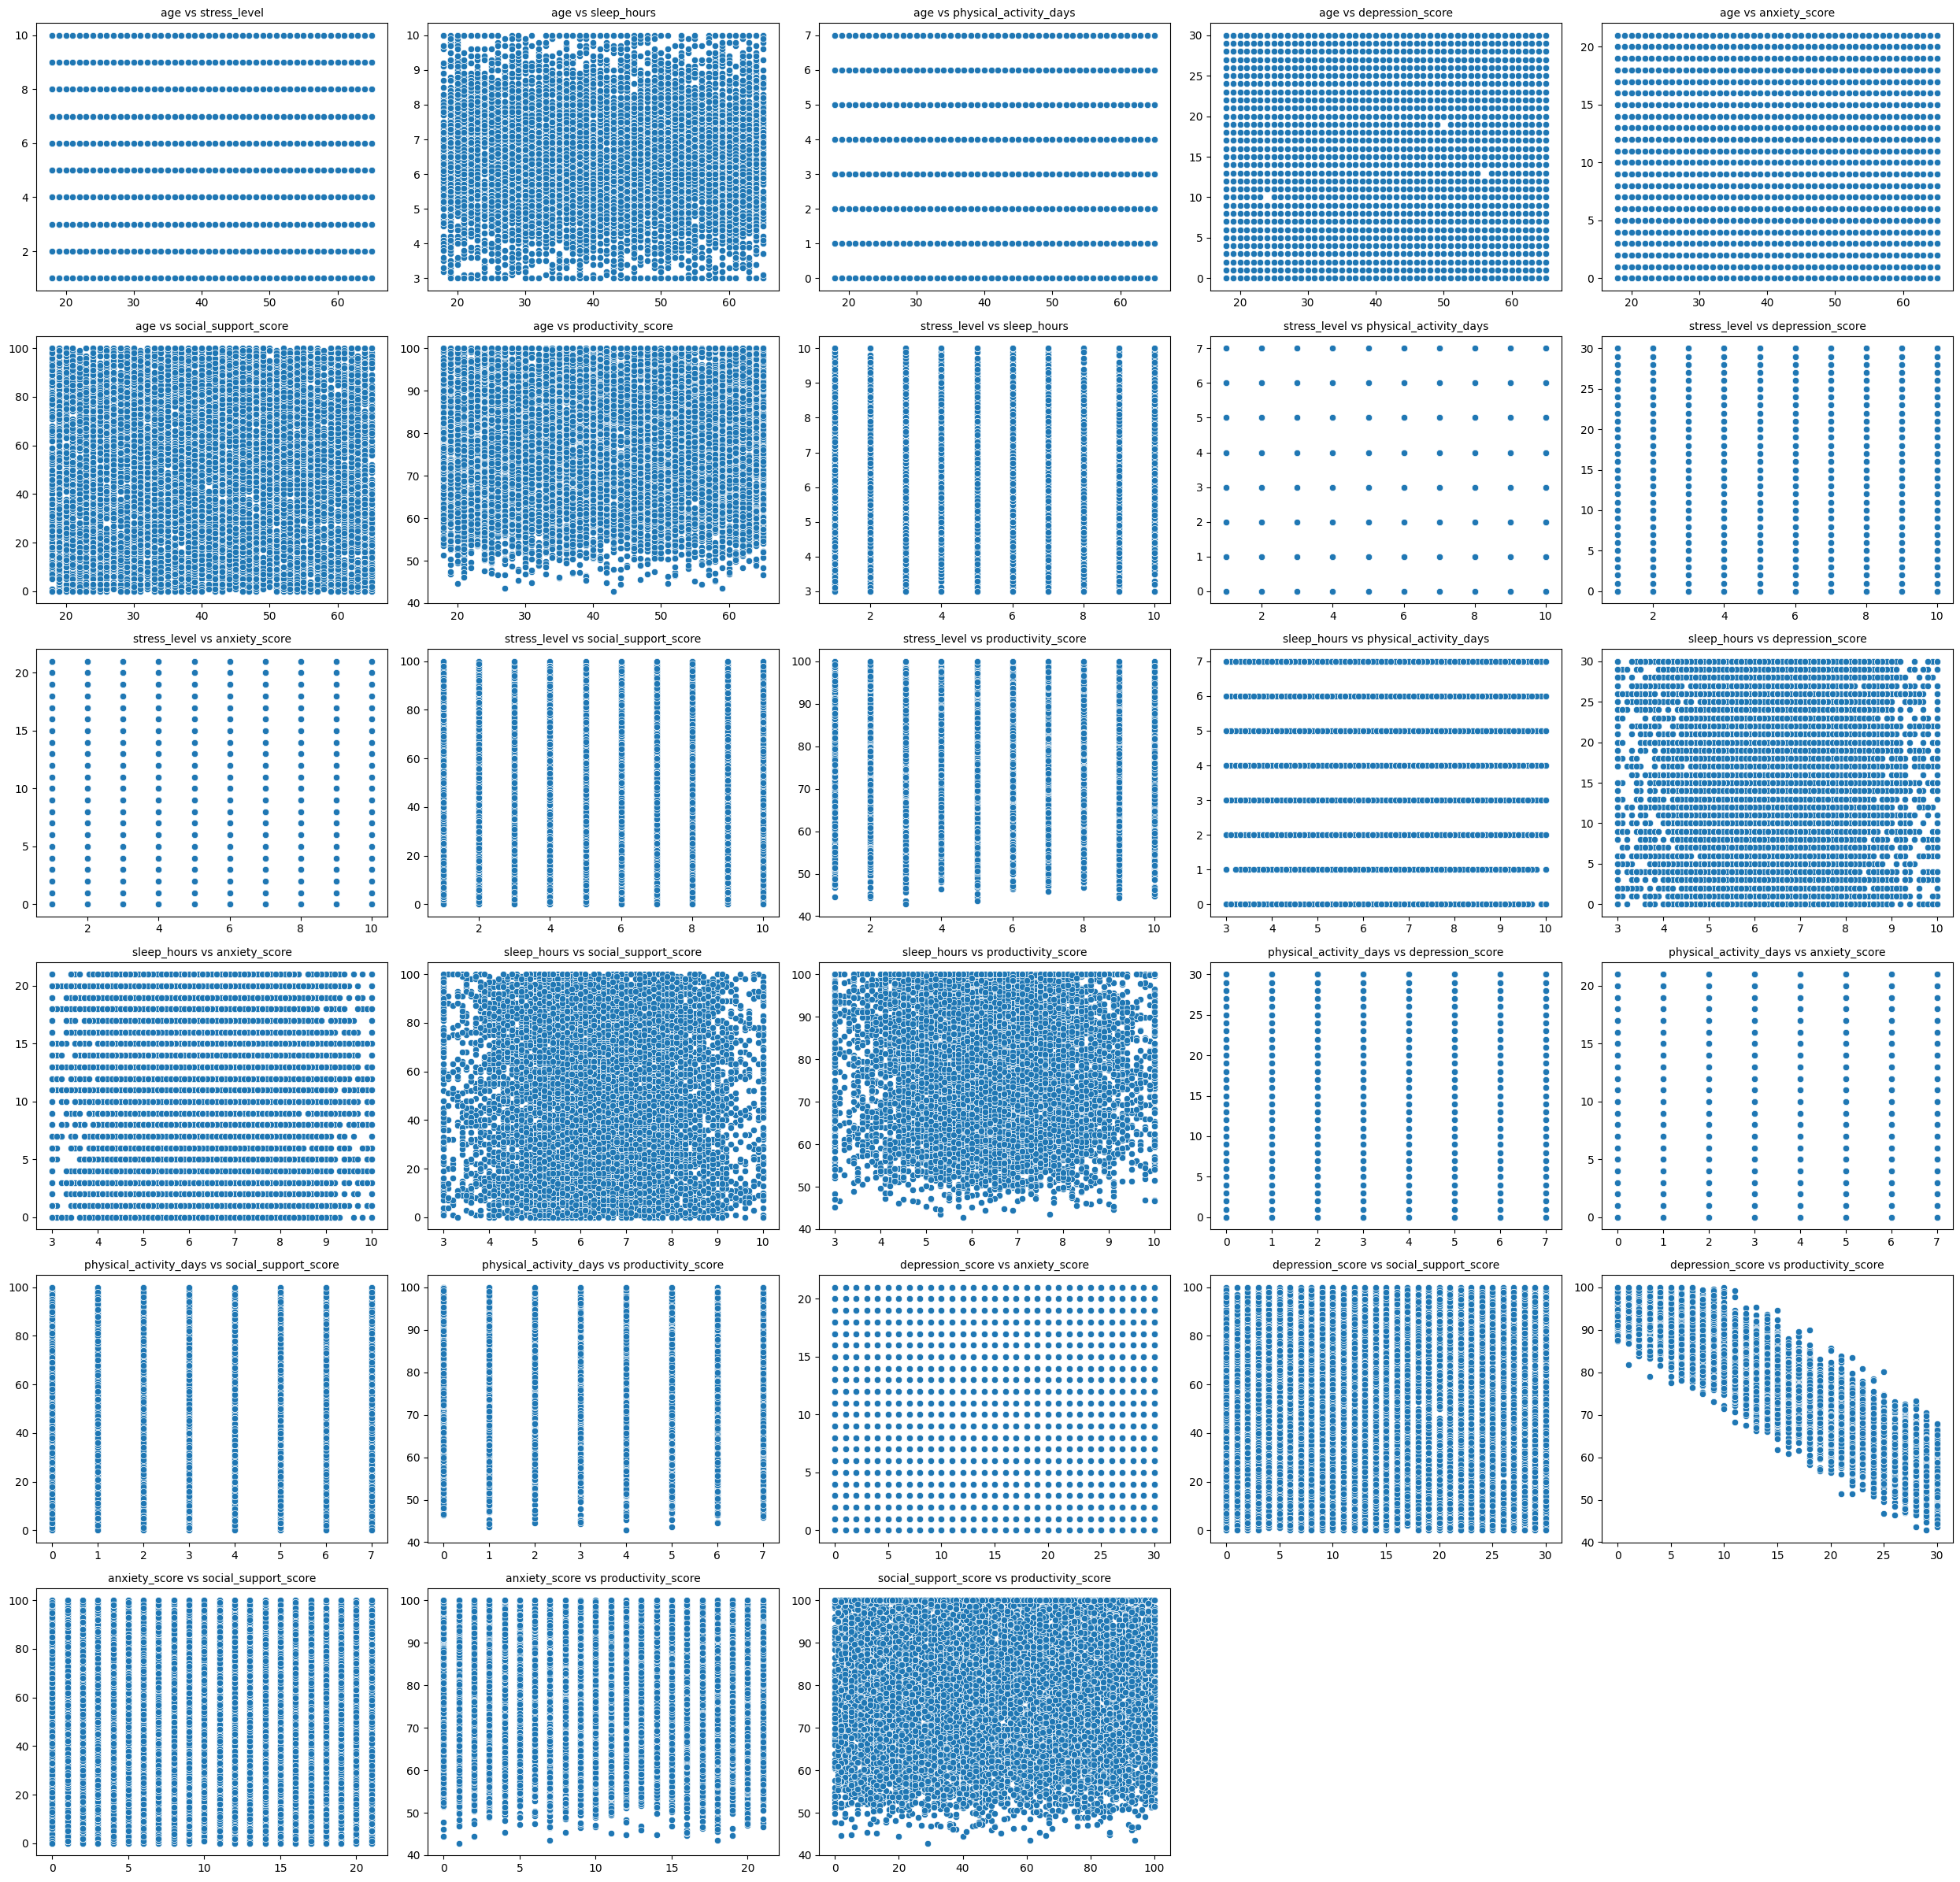

In [26]:
# 3. Scatter plots
pairs = [(num_cols[i], num_cols[j])
         for i in range(len(num_cols))
         for j in range(i+1, len(num_cols))]

n_plots = len(pairs)
plots_per_row = 5
rows = math.ceil(n_plots / plots_per_row)

plt.figure(figsize=(plots_per_row*5, rows*4))

for i, (x_col, y_col) in enumerate(pairs):
    plt.subplot(rows, plots_per_row, i+1)
    sns.scatterplot(x=df[x_col], y=df[y_col])
    plt.title(f'{x_col} vs {y_col}', fontsize=10)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

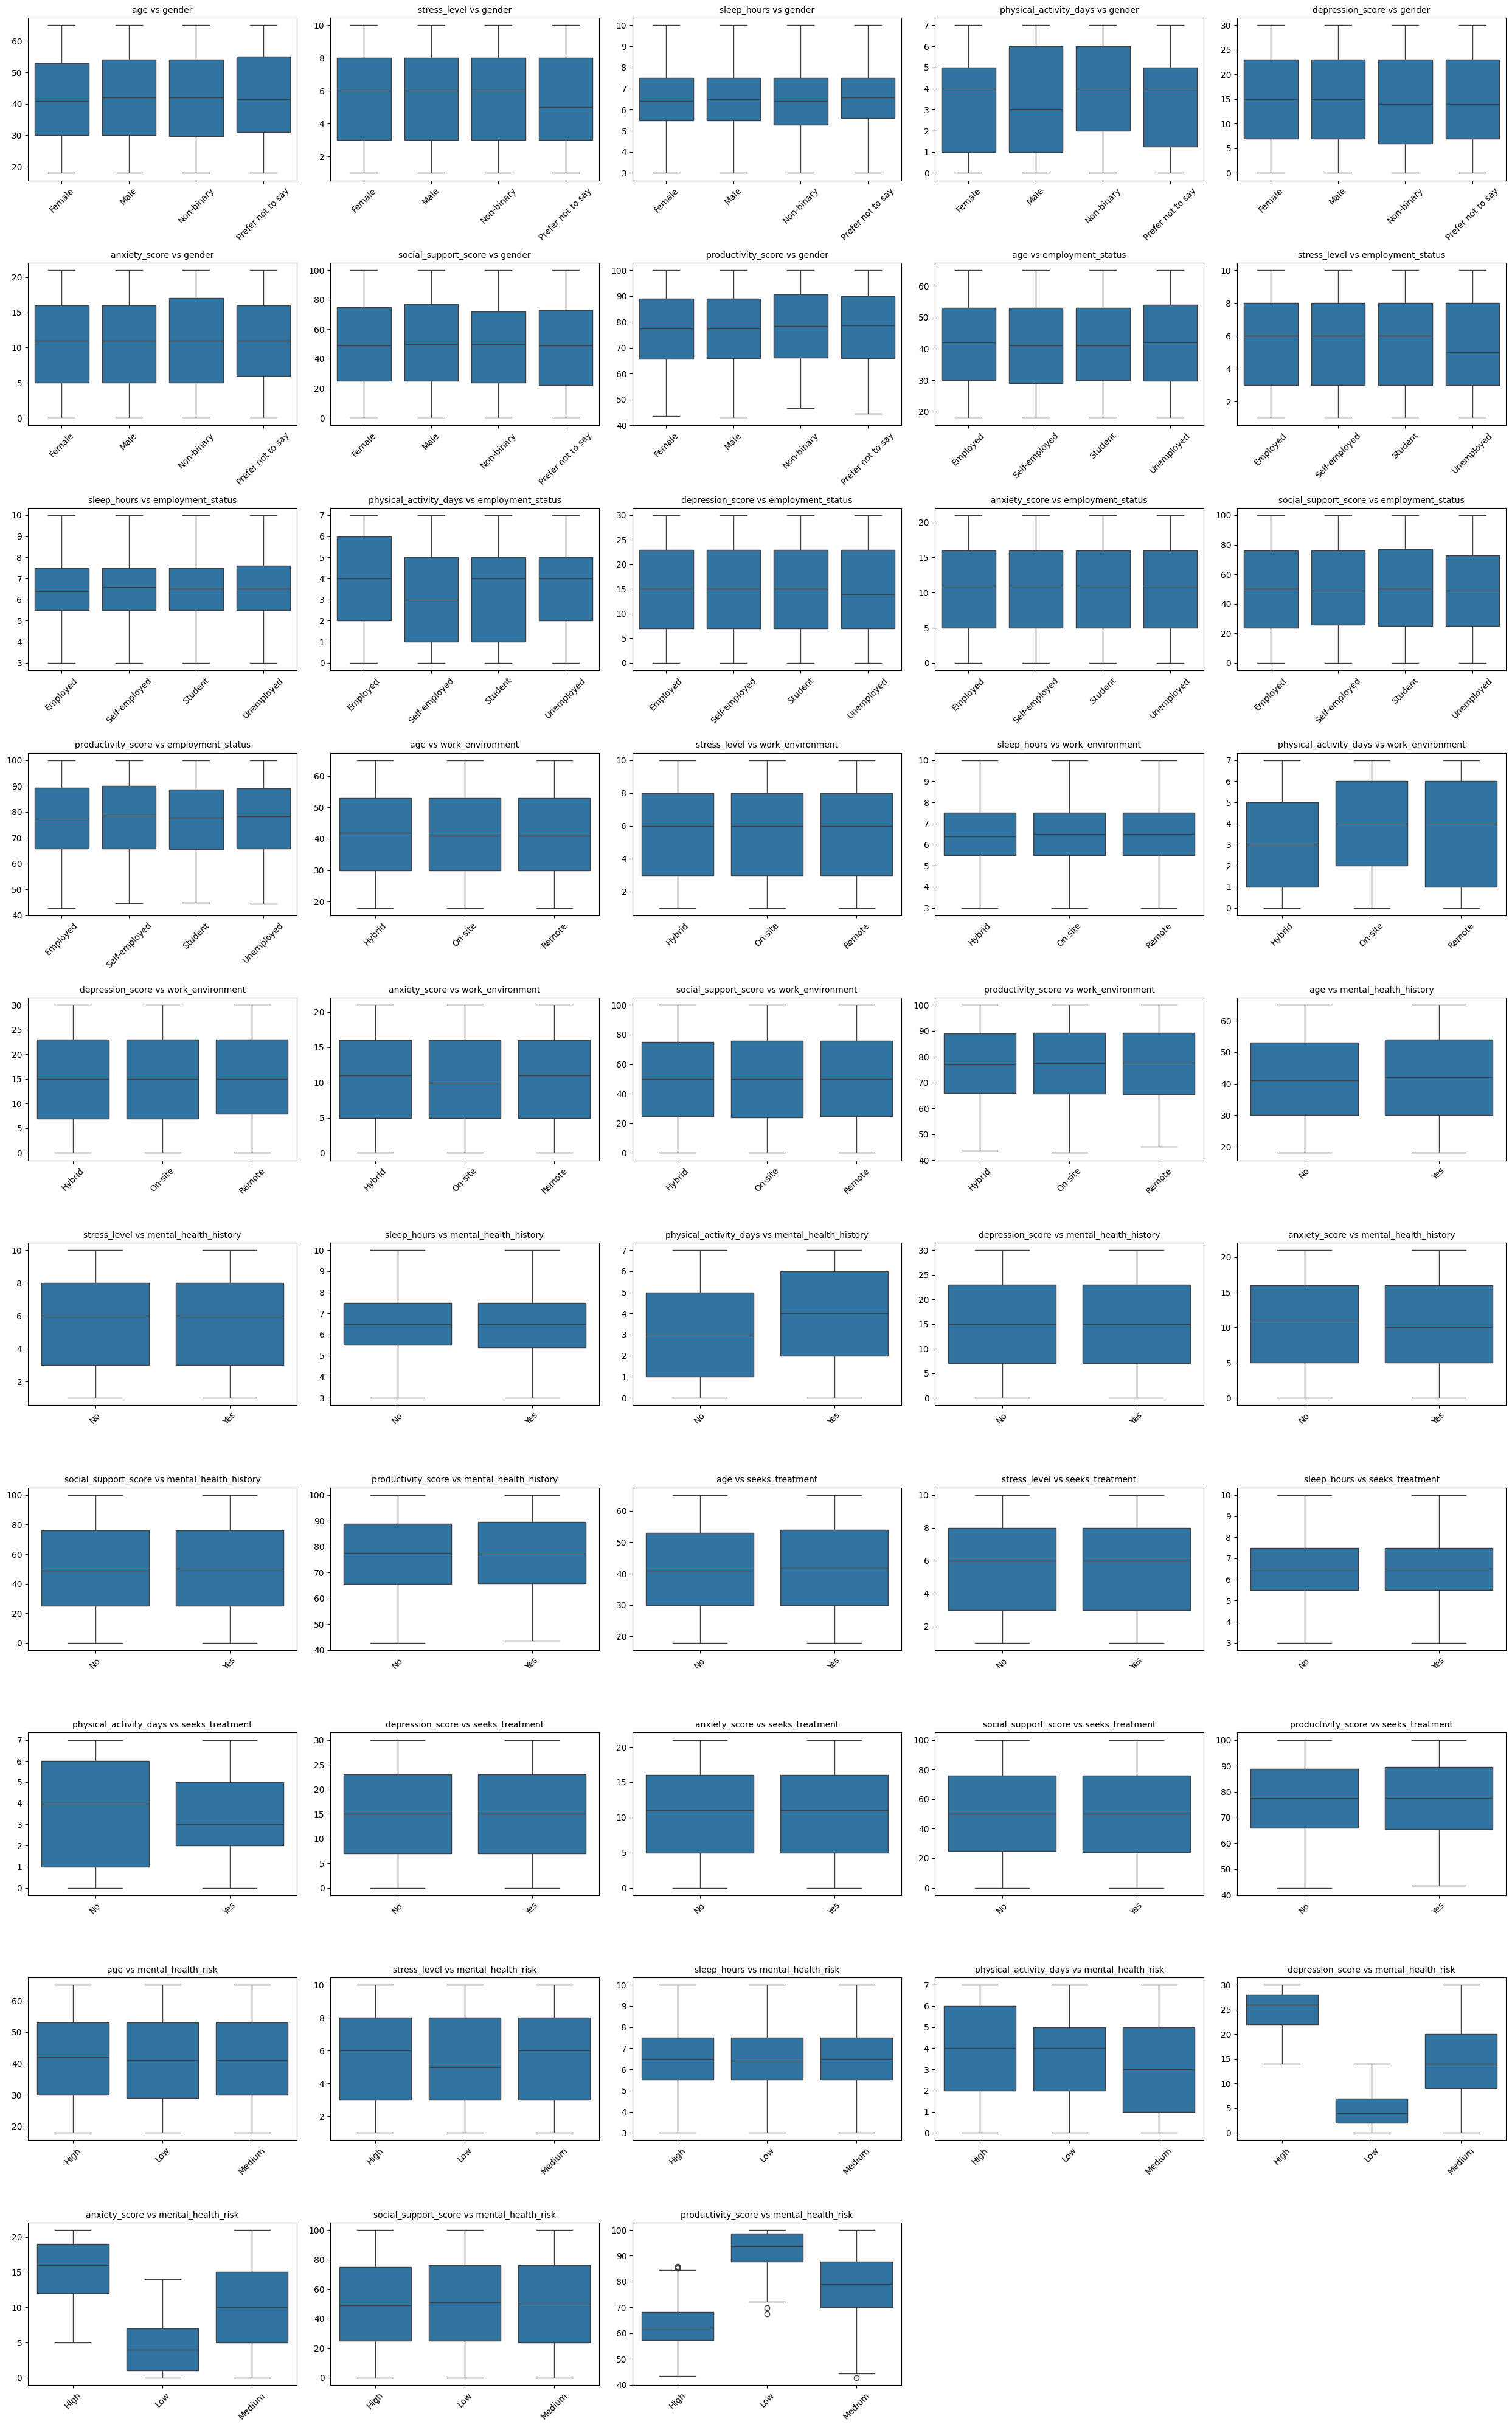

In [27]:
#  Boxplot (categorical vs numerical)
pairs = [(cat, num) for cat in cat_cols for num in num_cols]

n_plots = len(pairs)
plots_per_row = 5
rows = math.ceil(n_plots / plots_per_row)

plt.figure(figsize=(plots_per_row*5, rows*4))

for i, (cat, num) in enumerate(pairs):
    plt.subplot(rows, plots_per_row, i+1)
    sns.boxplot(x=df[cat], y=df[num])
    plt.title(f'{num} vs {cat}', fontsize=10)
    plt.xticks(rotation=45)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

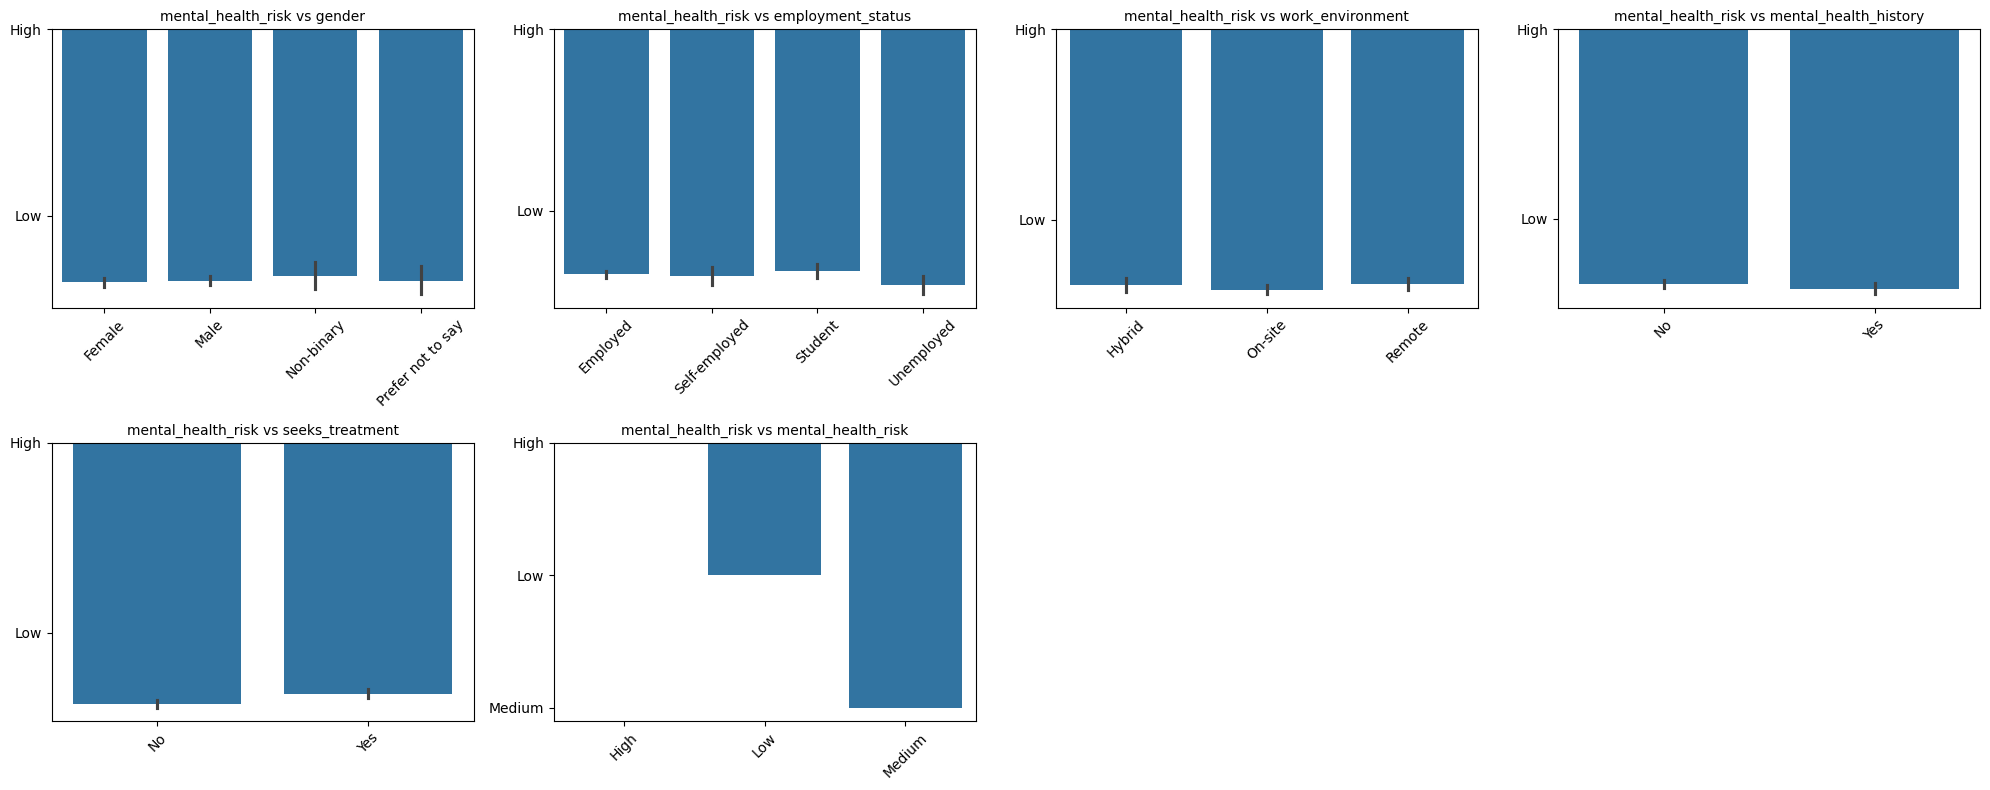

In [28]:
# Barplot (categorical vs target)

target_col = 'mental_health_risk'

if target_col in df.columns:

    n_plots = len(cat_cols)
    plots_per_row = 4
    rows = math.ceil(n_plots / plots_per_row)

    plt.figure(figsize=(plots_per_row*5, rows*4))

    for i, cat in enumerate(cat_cols):
        plt.subplot(rows, plots_per_row, i+1)
        sns.barplot(x=df[cat], y=df[target_col])
        plt.title(f'{target_col} vs {cat}', fontsize=10)
        plt.xticks(rotation=45)
        plt.xlabel('')
        plt.ylabel('')

    plt.tight_layout()
    plt.show()

In [29]:
# 5. GroupBy aggregations ==> The Same Barplot
for cat in cat_cols:
    for num in num_cols:
        print(f"\nMean of {num} grouped by {cat}:")
        print(df.groupby(cat)[num].mean())


Mean of age grouped by gender:
gender
Female               41.251963
Male                 41.797235
Non-binary           41.678846
Prefer not to say    42.002146
Name: age, dtype: float64

Mean of stress_level grouped by gender:
gender
Female               5.615885
Male                 5.516568
Non-binary           5.634615
Prefer not to say    5.624464
Name: stress_level, dtype: float64

Mean of sleep_hours grouped by gender:
gender
Female               6.465739
Male                 6.477727
Non-binary           6.400577
Prefer not to say    6.577039
Name: sleep_hours, dtype: float64

Mean of physical_activity_days grouped by gender:
gender
Female               3.498317
Male                 3.492210
Non-binary           3.644231
Prefer not to say    3.553648
Name: physical_activity_days, dtype: float64

Mean of depression_score grouped by gender:
gender
Female               15.039937
Male                 15.097433
Non-binary           14.776923
Prefer not to say    14.770386
Name: de

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9028\391585507.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(cat)[num].mean())


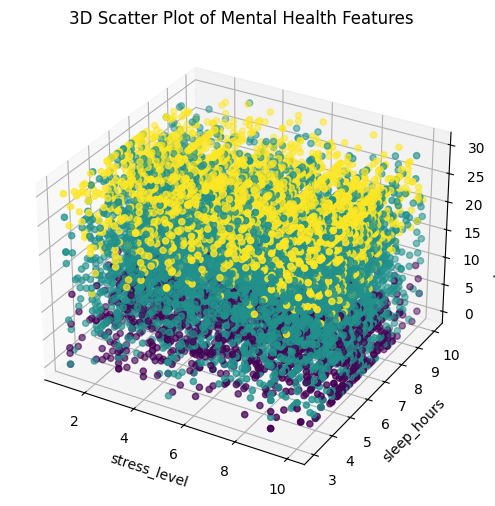

In [30]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

features_3d = ['stress_level', 'sleep_hours', 'depression_score']


df_temp = df.copy()

df_temp['mental_health_risk'] = df_temp['mental_health_risk'].map({
    'Low':0,
    'Medium':1,
    'High':2
})

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_temp[features_3d[0]],
    df_temp[features_3d[1]],
    df_temp[features_3d[2]],
    c=df_temp['mental_health_risk'],
    cmap='viridis'
)

ax.set_xlabel(features_3d[0])
ax.set_ylabel(features_3d[1])
ax.set_zlabel(features_3d[2])

plt.title("3D Scatter Plot of Mental Health Features")

plt.show()

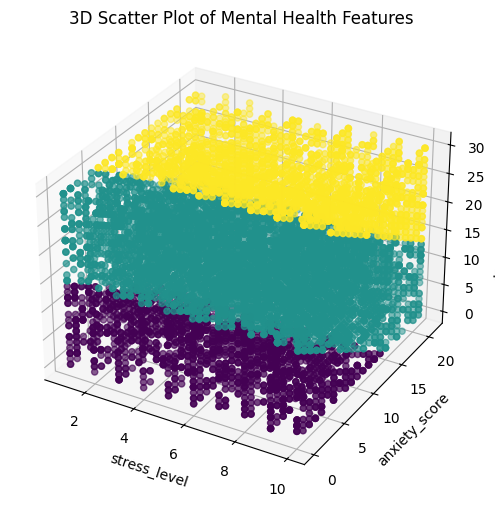

In [31]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

features_3d = ['stress_level','anxiety_score','depression_score']

df_temp = df.copy()

df_temp['mental_health_risk'] = df_temp['mental_health_risk'].map({
    'Low':0,
    'Medium':1,
    'High':2
})

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_temp[features_3d[0]],
    df_temp[features_3d[1]],
    df_temp[features_3d[2]],
    c=df_temp['mental_health_risk'],
    cmap='viridis'
)

ax.set_xlabel(features_3d[0])
ax.set_ylabel(features_3d[1])
ax.set_zlabel(features_3d[2])

plt.title("3D Scatter Plot of Mental Health Features")

plt.show()

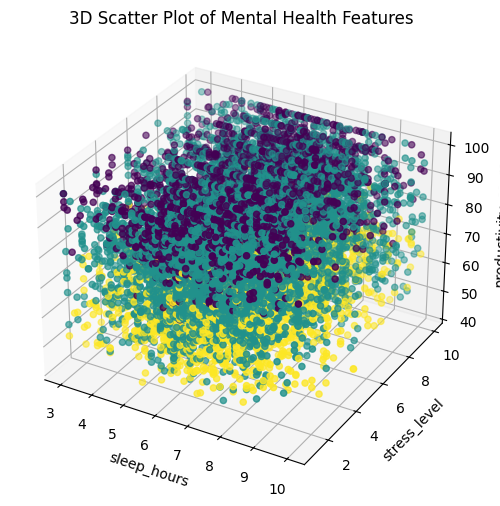

In [32]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

features_3d = ['sleep_hours','stress_level','productivity_score']

df_temp = df.copy()

df_temp['mental_health_risk'] = df_temp['mental_health_risk'].map({
    'Low':0,
    'Medium':1,
    'High':2
})

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_temp[features_3d[0]],
    df_temp[features_3d[1]],
    df_temp[features_3d[2]],
    c=df_temp['mental_health_risk'],
    cmap='viridis'
)

ax.set_xlabel(features_3d[0])
ax.set_ylabel(features_3d[1])
ax.set_zlabel(features_3d[2])

plt.title("3D Scatter Plot of Mental Health Features")

plt.show()

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

X = df.select_dtypes(include=[np.number])


vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

                  Feature        VIF
7      productivity_score  24.669970
2             sleep_hours  19.361779
0                     age   9.959148
4        depression_score   4.940441
1            stress_level   4.702647
6    social_support_score   3.926375
5           anxiety_score   3.776534
3  physical_activity_days   3.340336


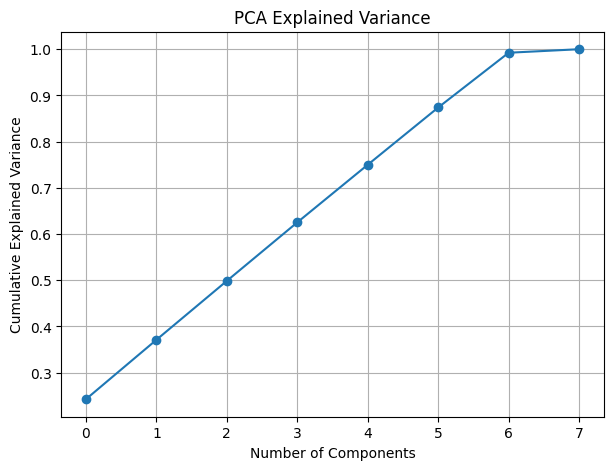

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

X = df.select_dtypes(include=[np.number])


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA()
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(7,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid()

plt.show()

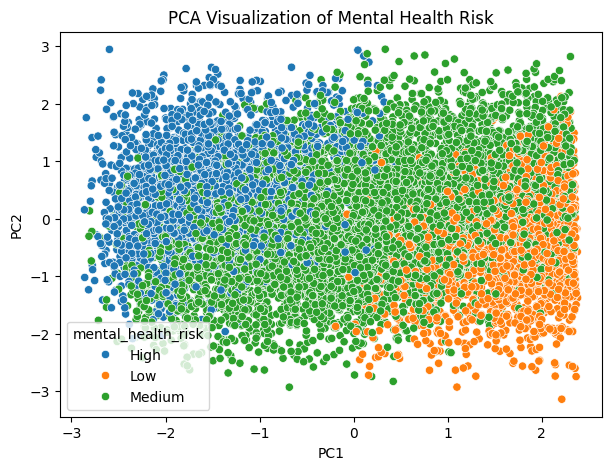

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

X = df.select_dtypes(include=['int64','float64'])

y = df['mental_health_risk']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA ل 2 Components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])

pca_df['mental_health_risk'] = y.values

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='mental_health_risk'
)

plt.title("PCA Visualization of Mental Health Risk")

plt.show()

## Encoding Categorical Variables ##  
Binary (Yes / No) 


In [36]:
df['mental_health_history'] = df['mental_health_history'].map({'No':0,'Yes':1})
df['seeks_treatment'] = df['seeks_treatment'].map({'No':0,'Yes':1})

## Target Encoding

Ordinal Encoding

In [37]:
df['mental_health_risk'] = df['mental_health_risk'].map({
    'Low':0,
    'Medium':1,
    'High':2
})

## One Hot Encoding

Nominal Data

In [38]:
df = pd.get_dummies(df, columns=[
    'gender',
    'employment_status',
    'work_environment'
], drop_first=True)

In [39]:
df.head()

,age,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk,gender_Male,gender_Non-binary,gender_Prefer not to say,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,work_environment_On-site,work_environment_Remote
0,56,1,1,6,6.2,3,28,17,54,59.7,2,True,False,False,False,False,False,True,False
1,46,0,1,10,9.0,4,30,11,85,54.9,2,False,False,False,False,True,False,True,False
2,32,1,0,7,7.7,2,24,7,62,61.3,1,False,False,False,False,False,False,True,False
3,60,0,0,4,4.5,4,6,0,95,97.0,0,False,True,False,True,False,False,True,False
4,25,1,1,3,5.4,0,24,12,70,69.0,2,False,False,False,True,False,False,True,False


In [40]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [41]:
df.dtypes

age                                   int64
mental_health_history              category
seeks_treatment                    category
stress_level                          int64
sleep_hours                         float64
physical_activity_days                int64
depression_score                      int64
anxiety_score                         int64
social_support_score                  int64
productivity_score                  float64
mental_health_risk                 category
gender_Male                           int64
gender_Non-binary                     int64
gender_Prefer not to say              int64
employment_status_Self-employed       int64
employment_status_Student             int64
employment_status_Unemployed          int64
work_environment_On-site              int64
work_environment_Remote               int64
dtype: object

In [42]:
df['mental_health_history'] = df['mental_health_history'].astype(int)
df['seeks_treatment'] = df['seeks_treatment'].astype(int)
df['mental_health_risk'] = df['mental_health_risk'].astype(int)

In [43]:
df.dtypes

age                                  int64
mental_health_history                int64
seeks_treatment                      int64
stress_level                         int64
sleep_hours                        float64
physical_activity_days               int64
depression_score                     int64
anxiety_score                        int64
social_support_score                 int64
productivity_score                 float64
mental_health_risk                   int64
gender_Male                          int64
gender_Non-binary                    int64
gender_Prefer not to say             int64
employment_status_Self-employed      int64
employment_status_Student            int64
employment_status_Unemployed         int64
work_environment_On-site             int64
work_environment_Remote              int64
dtype: object

In [44]:
df.head()

,age,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk,gender_Male,gender_Non-binary,gender_Prefer not to say,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,work_environment_On-site,work_environment_Remote
0,56,1,1,6,6.2,3,28,17,54,59.7,2,1,0,0,0,0,0,1,0
1,46,0,1,10,9.0,4,30,11,85,54.9,2,0,0,0,0,1,0,1,0
2,32,1,0,7,7.7,2,24,7,62,61.3,1,0,0,0,0,0,0,1,0
3,60,0,0,4,4.5,4,6,0,95,97.0,0,0,1,0,1,0,0,1,0
4,25,1,1,3,5.4,0,24,12,70,69.0,2,0,0,0,1,0,0,1,0


In [45]:
X = df.drop('mental_health_risk', axis=1)
y = df['mental_health_risk']


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##  Feature Scaling

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Without Smote

In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       348
           1       1.00      1.00      1.00      1178
           2       1.00      1.00      1.00       474

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## With Smote

In [48]:
from imblearn.over_sampling import SMOTE # SMOTTEN

smote = SMOTE(random_state=42)


X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)

Before SMOTE: (8000, 18)
After SMOTE: (14142, 18)


In [49]:
from sklearn.linear_model import LogisticRegression

model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       348
           1       1.00      0.99      1.00      1178
           2       0.99      1.00      0.99       474

    accuracy                           0.99      2000
   macro avg       0.99      1.00      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,     
    max_depth=None,       
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       348
           1       0.98      0.98      0.98      1178
           2       0.98      0.99      0.98       474

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



## Clustering (UnSupervised Learning)

In [51]:

X_cluster = df.drop(columns=['mental_health_risk'])

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)   
X_pca = pca.fit_transform(X_scaled)

X_pca = X_pca.T

In [ ]:
import skfuzzy as fuzz
import numpy as np

#  FCM

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_pca,
    c=3,
    m=1.5,
    error=0.005,
    maxiter=1000
)

#  Labels
fcm_labels = np.argmax(u, axis=0)

In [55]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil = silhouette_score(X_pca.T, fcm_labels)
dbi = davies_bouldin_score(X_pca.T, fcm_labels)

print("Silhouette:", sil)
print("DBI:", dbi)

Silhouette: 0.32354848754800025
DBI: 1.0814581502882945


In [56]:
import joblib

joblib.dump(rf_model, "modell.pkl")

['modell.pkl']

In [57]:


joblib.dump(X.columns, "columns.pkl")

['columns.pkl']